In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.Resize((224,224)), #change to 128 for vgg and res cuz they aren't workin
    transforms.Grayscale(num_output_channels=3),  # convert 1 channel -> 3
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5], [0.5,0.5,0.5])
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# train_dataset = torch.utils.data.Subset(train_dataset, range(50000))
# test_dataset = torch.utils.data.Subset(test_dataset, range(9000))

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)



In [2]:
vgg = models.vgg16(pretrained=True)  # imagenet
vgg.classifier[6] = nn.Linear(4096, 10)
for param in vgg.features.parameters():
    param.requires_grad = False

vgg = vgg.to(device)
resnet = models.resnet18(pretrained=True)
resnet.fc = nn.Linear(resnet.fc.in_features, 10)
# for param in resnet.parameters():
#     param.requires_grad = False
# resnet.fc.requires_grad = True
resnet = resnet.to(device)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
 

In [10]:
def train_model(model, train_loader, test_loader, epochs=3, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    epoch_losses = []
    epoch_accuracies = []
    all_preds_final = []
    all_labels_final = []


    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        avg_loss = running_loss / len(train_loader)
        epoch_losses.append(avg_loss)

    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

        acc = 100 * correct / total
        epoch_accuracies.append(acc)

        print(f"Epoch {epoch+1}/{epochs} — Loss: {avg_loss:.4f} — Accuracy: {acc:.2f}%")

        # Save final predictions and labels for confusion matrix
        all_preds_final = all_preds
        all_labels_final = all_labels

    return epoch_losses, epoch_accuracies, all_preds_final, all_labels_final


In [4]:
import matplotlib.pyplot as plt

def plot_loss_accuracy(losses, accuracies, model_name="Model"):
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.plot(range(1, len(losses)+1), losses, marker='o')
    plt.title(f"{model_name} - Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.subplot(1,2,2)
    plt.plot(range(1, len(accuracies)+1), accuracies, marker='o', color='green')
    plt.title(f"{model_name} - Test Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")

    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(preds, labels, model_name="Model"):
    cm = confusion_matrix(labels, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))
    disp.plot(cmap="Blues", values_format="d")
    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()


Training VGG16...
Epoch 5/5 — Loss: 0.1091 — Accuracy: 98.53%


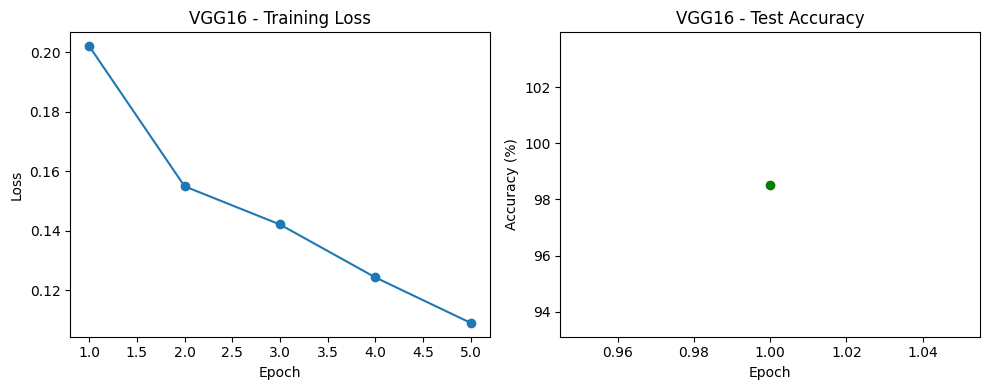

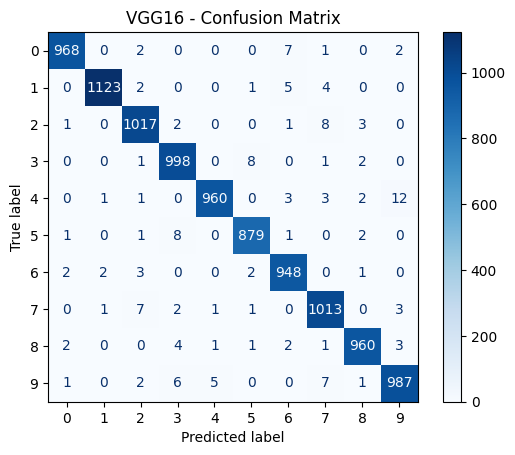

Training ResNet18...
Epoch 5/5 — Loss: 0.0187 — Accuracy: 99.22%


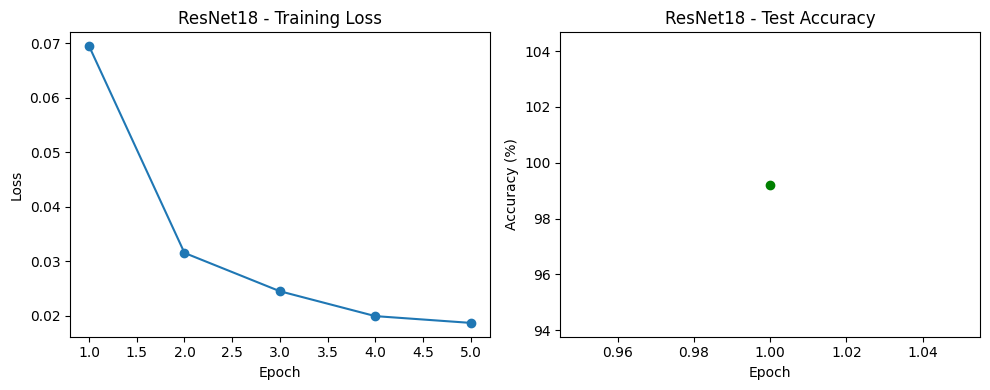

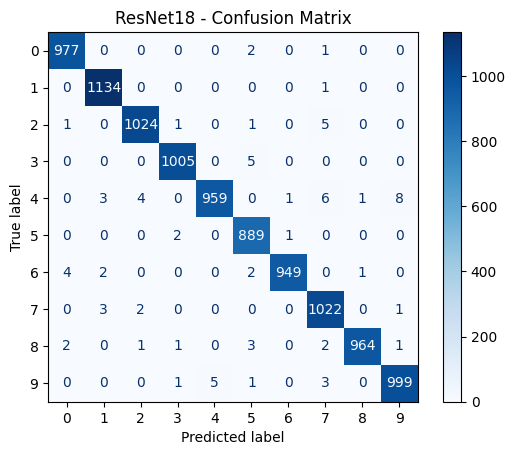

In [5]:
print("Training VGG16...")
vgg_losses, vgg_acc, vgg_preds, vgg_labels = train_model(vgg, train_loader, test_loader, epochs=5)
plot_loss_accuracy(vgg_losses, vgg_acc, "VGG16")
plot_confusion_matrix(vgg_preds, vgg_labels, "VGG16")

print("Training ResNet18...")
resnet_losses, resnet_acc, resnet_preds, resnet_labels = train_model(resnet, train_loader, test_loader, epochs=5)
plot_loss_accuracy(resnet_losses, resnet_acc, "ResNet18")
plot_confusion_matrix(resnet_preds, resnet_labels, "ResNet18")


In [ ]:
torch.save(vgg.state_dict(), 'vgg_mnist.pth')
torch.save(resnet.state_dict(), 'resnet_mnist.pth')

torch.save(vgg, 'vgg_mnist_full.pth')
torch.save(resnet, 'resnet_mnist_full.pth')

from google.colab import files

files.download('vgg_mnist.pth')
files.download('resnet_mnist.pth')

files.download('vgg_mnist_full.pth')
files.download('resnet_mnist_full.pth')

Training Vision Transformer...
Epoch 5/5 — Loss: 0.0151 — Accuracy: 99.33%


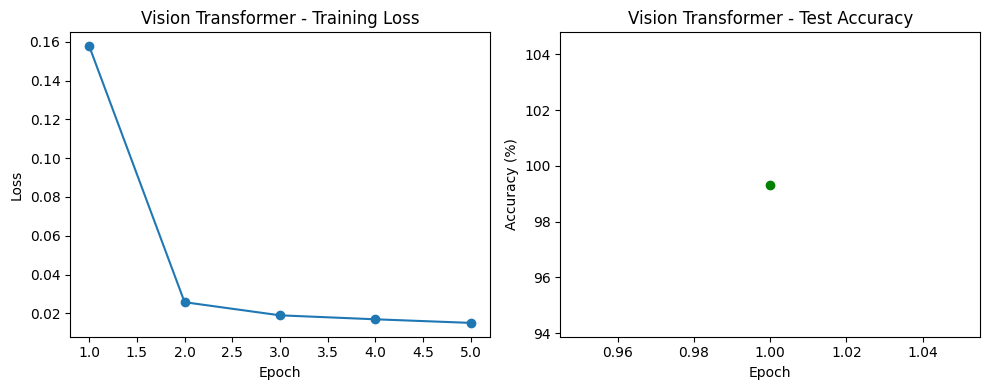

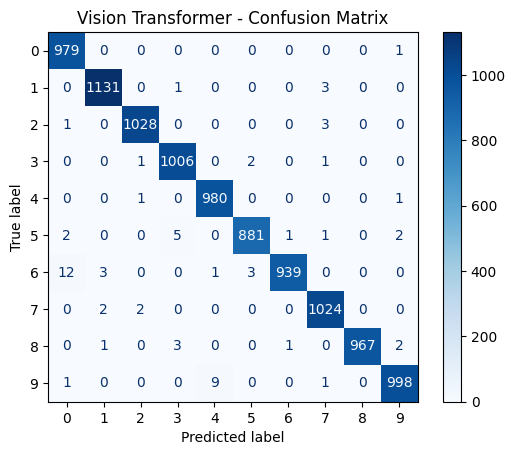

In [11]:
import timm
batch_size = 128

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


vit = timm.create_model('vit_tiny_patch16_224.augreg_in21k', pretrained=True)
vit.head = nn.Linear(vit.head.in_features, 10)
vit = vit.to(device)
print("Training Vision Transformer...")
vit_losses, vit_acc, vit_preds, vit_labels = train_model(vit, train_loader, test_loader, epochs=5, lr=1e-4)

plot_loss_accuracy(vit_losses, vit_acc, "Vision Transformer")
plot_confusion_matrix(vit_preds, vit_labels, "Vision Transformer")


In [ ]:
torch.save(vit.state_dict(), "vit_mnist.pth")
torch.save(vit, "vit_mnist_full.pth")
from google.colab import files

files.download("vit_mnist.pth")
files.download("vit_mnist_full.pth")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
from tqdm import tqdm
from torchvision import transforms
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def evaluate_yolo_vit(yolo, vit, test_loader, device):
    vit.eval()
    criterion = nn.CrossEntropyLoss()

    total_loss = 0
    correct = 0
    total = 0
    all_preds, all_labels = [], []

    transform_detect = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ])

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Evaluating YOLO+ViT"):
            for i in range(images.size(0)):
                img_tensor = images[i].cpu()
                label = labels[i].item()
                img_pil = transforms.ToPILImage()(img_tensor).convert("RGB")

                # YOLO detection
                results = yolo.predict(img_pil, verbose=False)[0]
                if len(results.boxes) > 0:
                    x1, y1, x2, y2 = map(int, results.boxes[0].xyxy[0])
                    cropped = img_pil.crop((x1, y1, x2, y2))
                else:
                    cropped = img_pil  # fallback

                input_tensor = transform_detect(cropped).unsqueeze(0).to(device)
                outputs = vit(input_tensor)
                loss = criterion(outputs, torch.tensor([label]).to(device))
                total_loss += loss.item()

                _, predicted = torch.max(outputs, 1)
                total += 1
                correct += (predicted.item() == label)
                all_preds.append(predicted.item())
                all_labels.append(label)

    avg_loss = total_loss / total
    accuracy = 100 * correct / total
    return avg_loss, accuracy, all_preds, all_labels


In [ ]:
vit_yolo_loss, vit_yolo_acc, vit_yolo_preds, vit_yolo_labels = evaluate_yolo_vit(
    yolo, vit, test_loader, device
)

print(f"ViT+YOLO Evaluation Complete — Loss: {vit_yolo_loss:.4f} — Accuracy: {vit_yolo_acc:.2f}%")


In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot([1], [vit_yolo_loss], marker='o')
plt.title("YOLO+ViT - Evaluation Loss")
plt.xlabel("Run")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.plot([1], [vit_yolo_acc], marker='o', color='green')
plt.title("YOLO+ViT - Evaluation Accuracy")
plt.xlabel("Run")
plt.ylabel("Accuracy (%)")

plt.tight_layout()
plt.show()

# Confusion matrix
cm = confusion_matrix(vit_yolo_labels, vit_yolo_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))
disp.plot(cmap="Blues", values_format="d")
plt.title("YOLO+ViT - Confusion Matrix")
plt.show()
